# Rayleigh Fading Channel — Unknown $C_k$ (Gibbs + Kalman)

We extend the known-$C_k$ setup (see `kalman_rayleigh.ipynb`) to infer both the discrete bits $C_k\in\{-1,1\}$ and the continuous fading process $W_k$ when $C_k$ is unknown.

Model (same notation):
- State (fading): $W_k = \rho W_{k-1} + U_k$, with $U_k\sim\mathcal{N}(0, \sigma_u^2)$.\n
- Observation: $Y_k = C_k W_k + V_k$, with $V_k\sim\mathcal{N}(0, \sigma_v^2)$ and $C_k\in\{-1,1\}$ (i.i.d. fair).

Inference approach (Rao–Blackwellized Gibbs):
- Sample $W_{0:n-1} \mid C_{0:n-1}, Y_{0:n-1}$ using a Kalman filter and simulation smoother (Carter–Kohn).
- Sample $C_k \mid W_k, Y_k$ independently with
  $\Pr(C_k=+1 \mid W_k,Y_k) = \mathrm{sigmoid}(\frac{ Y_k W_k}{  \sigma_v^2})$.

We report: (i) theoretical vs predicted $C_k$, (ii) theoretical vs predicted $W_k$, and (iii) NRMSE for $W_k$.

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Tuple, Optional, Dict

np.set_printoptions(suppress=True, precision=4)

def set_seed(seed: int = 0) -> None:
    np.random.seed(seed)

def nrmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    denom = np.std(y_true) if np.std(y_true) > 0 else 1.0
    return rmse / denom


## Simulation (same as known-$C_k$ notebook)

In [28]:
def simulate_system(n: int, rho: float, sigma_u: float, sigma_v: float) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Returns:
        C_k: bits in {-1, 1}
        W_k: AR(1) fading coefficients
        Y_k: observations Y_k = C_k * W_k + V_k
    """
    C_k = np.random.choice([-1, 1], size=n)

    W_k = np.zeros(n)
    U_k = np.random.normal(0.0, sigma_u, size=n)
    # Stationary initialization for AR(1)
    W_k[0] = np.random.normal(0.0, sigma_u / np.sqrt(max(1e-12, 1.0 - rho ** 2)))
    for k in range(1, n):
        W_k[k] = rho * W_k[k - 1] + U_k[k]

    V_k = np.random.normal(0.0, sigma_v, size=n)
    Y_k = C_k * W_k + V_k
    return C_k, W_k, Y_k


## Kalman filter with time-varying observation $H_k = C_k$

In [29]:
def kalman_filter_forward(
    Y_k: np.ndarray,
    C_k: np.ndarray,
    rho: float,
    sigma_u: float,
    sigma_v: float,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Standard 1D Kalman filter where the observation matrix is H_k = C_k.
    Returns filtered means/covariances (m, P) and one-step predictions (a_next, R_next).
    m[k], P[k] = p(W_k | Y_{0:k});  a_next[k], R_next[k] = p(W_{k+1} | Y_{0:k}).
    """
    n = len(Y_k)
    m = np.zeros(n)
    P = np.zeros(n)
    a_next = np.zeros(n)
    R_next = np.zeros(n)

    # Prior (stationary)
    m_prior = 0.0
    P_prior = sigma_u ** 2 / max(1e-12, (1.0 - rho ** 2))

    for k in range(n):
        # Predict to time k
        if k == 0:
            a_k = m_prior
            R_k = P_prior
        else:
            a_k = rho * m[k - 1]
            R_k = (rho ** 2) * P[k - 1] + sigma_u ** 2

        # Update with observation y_k = C_k * w_k + v_k
        H_k = C_k[k]
        S_k = (H_k ** 2) * R_k + sigma_v ** 2
        K_k = R_k * H_k / S_k
        innov = Y_k[k] - H_k * a_k
        m[k] = a_k + K_k * innov
        P[k] = (1.0 - K_k * H_k) * R_k

        # One-step prediction to k+1 (used by RTS/simulation smoother)
        a_next[k] = rho * m[k]
        R_next[k] = (rho ** 2) * P[k] + sigma_u ** 2

    return m, P, a_next, R_next

def sample_state_trajectory(
    m: np.ndarray, P: np.ndarray, a_next: np.ndarray, R_next: np.ndarray, rho: float
) -> np.ndarray:
    """
    Carter–Kohn simulation smoother for 1D AR(1):
    samples W_{0:n-1} ~ p(W | Y, C).
    """
    n = len(m)
    W = np.zeros(n)
    # Start from the filtering distribution at n-1 (equals smoothing at final time)
    W[-1] = np.random.normal(m[-1], np.sqrt(max(P[-1], 0.0)))
    for k in range(n - 2, -1, -1):
        # Conditional p(W_k | W_{k+1}, Y) is Gaussian
        J_k = P[k] * rho / max(R_next[k], 1e-12)
        mean_k = m[k] + J_k * (W[k + 1] - a_next[k])
        var_k = P[k] - J_k * J_k * R_next[k]
        var_k = max(var_k, 0.0)
        W[k] = np.random.normal(mean_k, np.sqrt(var_k))
    return W


## Gibbs sampler for unknown $C_k$

In [30]:
def sample_C_given_WY(W: np.ndarray, Y: np.ndarray, sigma_v: float) -> np.ndarray:
    """
    Sample C_k in {-1, +1} from p(C_k | W_k, Y_k).
    p(C_k=+1|W_k,Y_k) = sigmoid(2 Y_k W_k / sigma_v^2).
    """
    logits = (2.0 * Y * W) / (sigma_v ** 2)
    p_plus = 1.0 / (1.0 + np.exp(-np.clip(logits, -50, 50)))
    u = np.random.rand(len(W))
    C = np.where(u < p_plus, 1, -1).astype(int)
    return C

def gibbs_inference(
    Y_k: np.ndarray,
    rho: float,
    sigma_u: float,
    sigma_v: float,
    n_iter: int = 400,
    burn_in: int = 150,
    init_C: Optional[np.ndarray] = None,
    seed: Optional[int] = 0,
) -> Dict[str, np.ndarray]:
    """
    Rao–Blackwellized Gibbs sampler for the Rayleigh fading model with unknown bits.
    Returns posterior summaries for C and W.
    """
    if seed is not None:
        set_seed(seed)
    n = len(Y_k)
    # Initialize C: by sign(Y) is a decent heuristic
    if init_C is None:
        init_C = np.where(Y_k >= 0, 1, -1).astype(int)
    C = init_C.copy()

    # Accumulators post burn-in
    W_sum = np.zeros(n)
    C_sum = np.zeros(n)
    kept = 0

    last_W = np.zeros(n)
    last_C = C.copy()

    for it in range(n_iter):
        # 1) W | C, Y using Kalman + simulation smoother
        m, P, a_next, R_next = kalman_filter_forward(Y_k, C, rho, sigma_u, sigma_v)
        W = sample_state_trajectory(m, P, a_next, R_next, rho)

        # 2) C | W, Y (independent across k)
        C = sample_C_given_WY(W, Y_k, sigma_v)

        # Collect after burn-in
        if it >= burn_in:
            W_sum += W
            C_sum += C
            kept += 1
        last_W = W
        last_C = C

    # Posterior means and MAP bits
    W_mean = W_sum / max(1, kept)
    C_mean = C_sum / max(1, kept)
    C_map = np.where(C_mean >= 0, 1, -1).astype(int)

    return {
        'W_mean': W_mean,
        'C_mean': C_mean,
        'C_map': C_map,
        'last_W': last_W,
        'last_C': last_C,
        'm_filt': m,
        'P_filt': P,
    }


## Run experiment and plot results

<>:27: SyntaxWarning: invalid escape sequence '\h'
<>:35: SyntaxWarning: invalid escape sequence '\h'
<>:27: SyntaxWarning: invalid escape sequence '\h'
<>:35: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_14146/1887636313.py:27: SyntaxWarning: invalid escape sequence '\h'
  axes[0].step(t, C_hat, where='post', label='Predicted $\hat{C}_k$', linestyle='--')
/tmp/ipykernel_14146/1887636313.py:35: SyntaxWarning: invalid escape sequence '\h'
  axes[1].plot(t, W_hat, label='Predicted $\hat{W}_k$ (posterior mean)', linestyle='--')


NRMSE(W): 1.355  |  Bit accuracy: 0.498


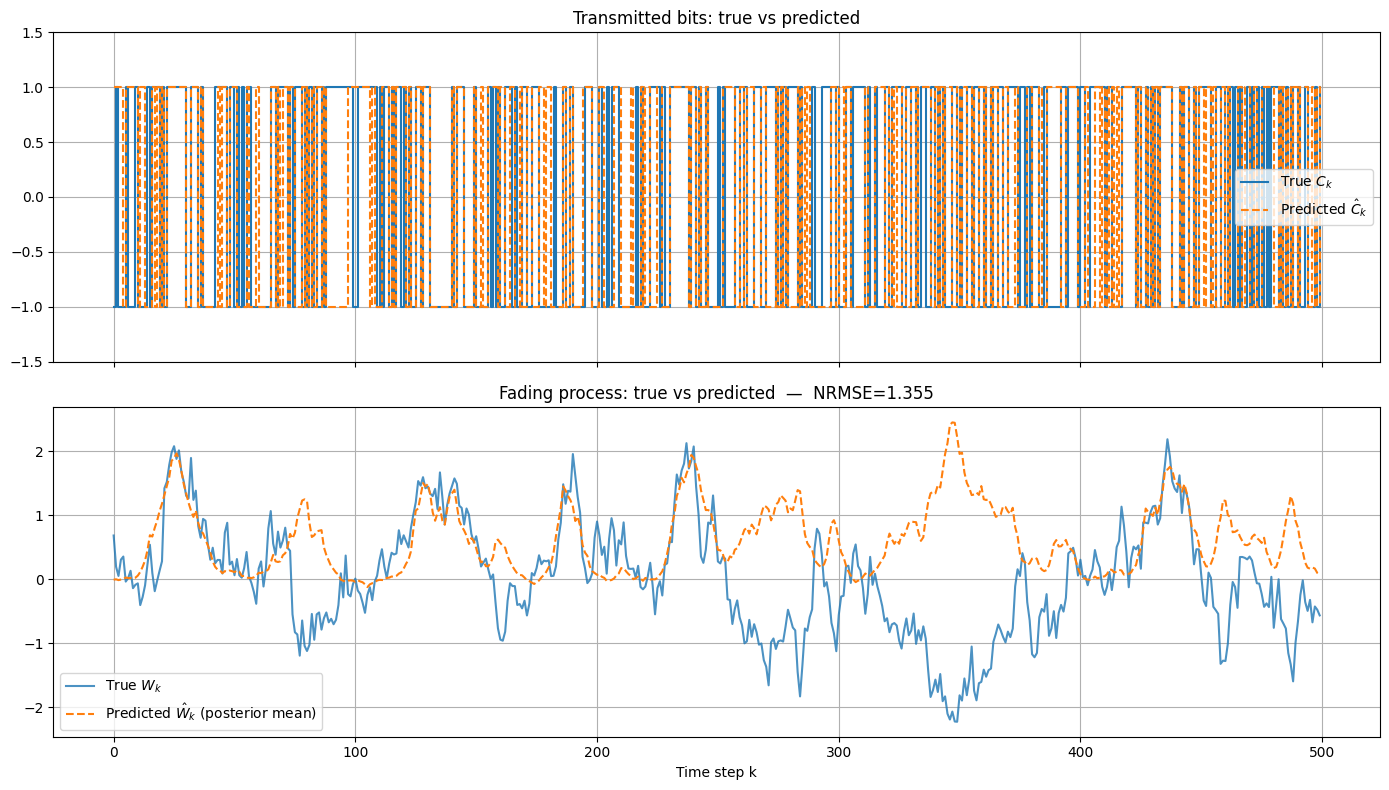

In [31]:
# Parameters (match known-C_k notebook style)
set_seed(42)
n = 500
rho = 0.95
sigma_u = 0.3
sigma_v = 0.5

# Simulate ground truth
C_true, W_true, Y = simulate_system(n, rho, sigma_u, sigma_v)

# Inference with Gibbs
res = gibbs_inference(Y, rho, sigma_u, sigma_v, n_iter=400, burn_in=150, seed=123)
W_hat = res['W_mean']
C_hat = res['C_map']

# Metrics
nrmse_val = nrmse(W_true[1:], W_hat[1:])
bit_acc = np.mean(C_true == C_hat)
print(f'NRMSE(W): {nrmse_val:.3f}  |  Bit accuracy: {bit_acc:.3f}')

# Plots: C_k (true vs predicted) and W_k (true vs predicted)
t = np.arange(n)
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# C_k
axes[0].step(t, C_true, where='post', label='True $C_k$', linewidth=1.5)
axes[0].step(t, C_hat, where='post', label='Predicted $\hat{C}_k$', linestyle='--')
axes[0].set_ylim(-1.5, 1.5)
axes[0].set_title('Transmitted bits: true vs predicted')
axes[0].grid(True)
axes[0].legend()

# W_k
axes[1].plot(t, W_true, label='True $W_k$', alpha=0.8)
axes[1].plot(t, W_hat, label='Predicted $\hat{W}_k$ (posterior mean)', linestyle='--')
axes[1].set_title(f'Fading process: true vs predicted  —  NRMSE={nrmse_val:.3f}')
axes[1].grid(True)
axes[1].legend()

plt.xlabel('Time step k')
plt.tight_layout()
plt.show()
